# Class 7: Machine Learning Workflows for Network Data

Goals of today's class:
1. Overview of machine learning in general
2. Introduce several classic ML models (linear and logistic regression, decision trees, random forests)
3. Introduce foundational ML topics (model evaluation, train/test split, cross-validation)
4. Apply machine learning to network problems
__________

1. Come in. Sit down. Open Teams.
2. Make sure your notebook from last class is saved.
________

In [1]:
%load_ext jupyter_tikz

In [2]:
import networkx as nx
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sklearn
from tqdm.notebook import tqdm
# pip install tqdm ipywidgets for the above progress bar

#plt.rcParams['figure.dpi'] = 300
#plt.rcParams['savefig.dpi'] = 300
#plt.rcParams['text.usetex'] = True

### What is Machine Learning?

_Machine learning_ describes a set of statistical techniques for finding predictive patterns in data. Typically, we will have one or more input variables (called _features_ or _predictors_ and denoted $X$) and one output variable (sometimes called a _response_ variable or a _label_, denoted $\hat{y}$).

Machine learning can be broken into two broad categories, supervised and unsupervised:

* In _supervised_ machine learning we have a series of input data and are trying to find a relationship between multiple features and a _known_ label. For example, "here are labeled photos of cats and dogs, build a machine that can distinguish between the two," or "we are a life insurance company: based on these spreadsheets of health information, predict lifespan."

* In _unsupervised_ machine learning we do _not_ have any ground truth labels, and are trying to fit the best pattern possible. For example, clustering, dimensionality reduction, missing value imputation, or outlier detection. Most community detection falls into this category.

Today we will primarily be focusing on _supervised_ machine learning. Supervised tasks can be broken into two further categories:

* Classification: produce a categorical label from input data (i.e. "predict whether this is a photo of a cat or a dog")

* Regression: produce a numeric prediction from input data (i.e. "predict lifespan," "predict bird beak length", etc)

Both tasks are closely related, so the algorithms for classification and regression are often quite similar, but model performance is measured a little differently when the former has discrete outputs and the latter is continuous.

### An Enormous Caveat!

Machine learning is a wide field. We could spend many semesters on it. We are spending one afternoon on it instead. We will have neither breadth nor depth, but a little bit of a mix. After today you should walk away with a loose understanding of machine learning concepts, such as regression, classification, model performance, test/train splits, ensembles, dimensionality reduction, and decorrelation. You will also have a handful of foundational machine learning models in your tool belt. Between the two, you will be better prepared to learn more on your own as needed for your research.

### Linear Regression

Let's jump in with an example that will motivate more theory. Linear regression: fitting a line to some data. You may have done this with a straight line predicting Y from X since high school or even earlier. We're doing it again in Python!

We got an R^2 of 0.474


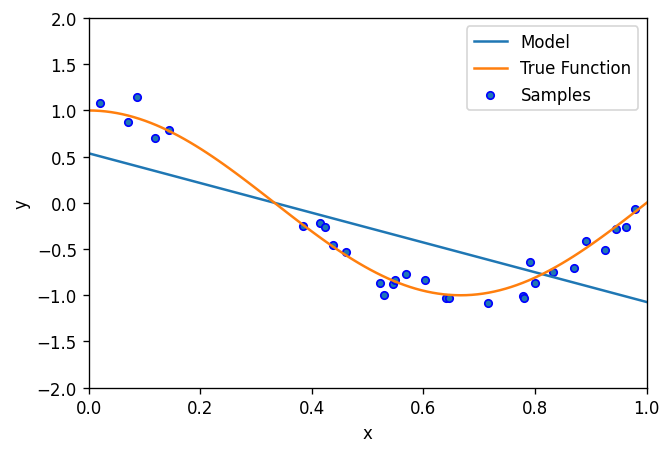

In [3]:
from sklearn.linear_model import LinearRegression

# Adapted from https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 30

X = np.sort(np.random.rand(n_samples))
X_rotated = X.reshape(-1, 1) # Make this an Nx1 array instead of 1xN
y = true_fun(X) + np.random.randn(n_samples) * 0.1 # True function with a little noise

reg = LinearRegression().fit(X_rotated, y)
score = reg.score(X_rotated, y)
print("We got an R^2 of %.3f" % score)

X_test = np.linspace(0, 1, 100)
X_test_rotated = X_test.reshape(-1,1)
plt.figure(figsize=(6,4), dpi=120)
plt.plot(X_test, reg.predict(X_test_rotated), label="Model")
plt.plot(X_test, true_fun(X_test), label="True Function")
plt.scatter(X, y, edgecolor="b", s=20, label="Samples")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim((0,1))
plt.ylim((-2,2))
plt.legend(loc="best")
plt.show()

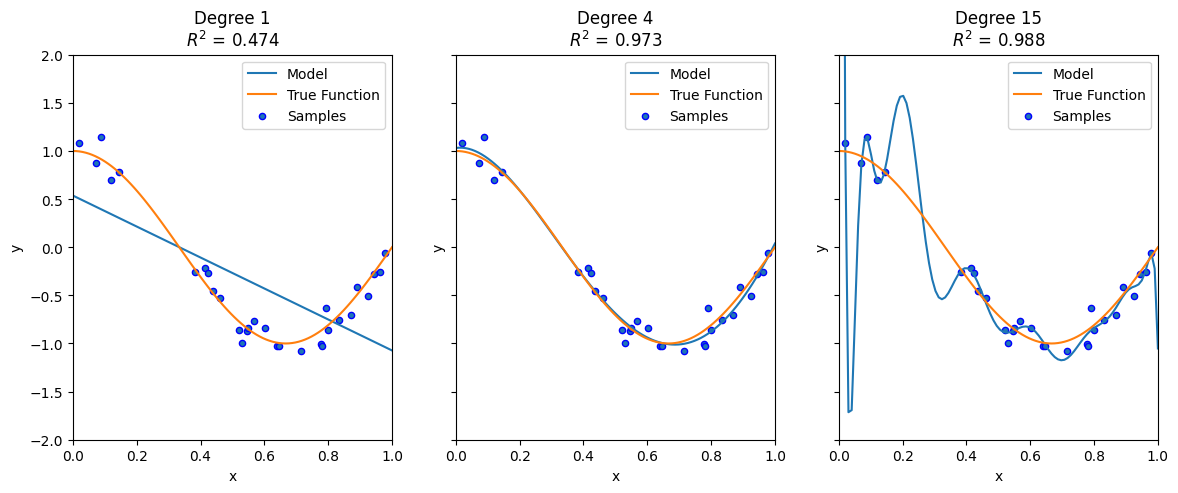

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

degrees = [1, 4, 15]

fig, axs = plt.subplots(1, 3, figsize=(14,5), sharex=True, sharey=True)
for i,degree in enumerate(degrees):
    ax = axs[i]
    expanded_features = PolynomialFeatures(degree).fit_transform(X_rotated)
    reg = LinearRegression().fit(expanded_features, y)
    score = reg.score(expanded_features, y)

    X_test = np.linspace(0, 1, 100)
    X_test_rotated = PolynomialFeatures(degree).fit_transform(X_test.reshape(-1,1))
    ax.plot(X_test, reg.predict(X_test_rotated), label="Model")
    ax.plot(X_test, true_fun(X_test), label="True Function")
    ax.scatter(X, y, edgecolor="b", s=20, label="Samples")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.xlim((0,1))
    plt.ylim((-2,2))
    ax.legend(loc="best")
    ax.set_title("Degree %d\n$R^2$ = %.3f" % (degree,score))
plt.show()

#### What's going on?

With a polynomial of degree 1, we're fitting $\hat{y} = mx + b$, where linear regression is fitting two variables to our data: $m$ and $b$. In order to fit our line to data we need some metric of how good a fit we have, commonly called a **loss function** or **error function**. Common choices are mean-squared error (MSE), and mean-absolute error (MAE). Above we're using MSE, where $error = \sum (y - \hat{y})^2$. This minimimizes the importance of small errors, and magnifies the importance of large errors. We adjust $m$ and $b$ experimentally until we find the lowest possible error score.

Note that rather than displaying MSE directly, we present it as an $R^2$ score, which is defined as $1 - \frac{u}{v}$ where $u$ is MSE and $v$ is $\sum (y - \bar{y})^2$. This ranges from $(-\infty,1]$ where 1 is a perfect score and 0 is "guesses $\bar{y}$ for every input."

When we increase the degree of the polynomial to 4, we are now fitting $y = m_1 x + m_2 x^2 + m_3 x^3 + m_4 x^4 + b$, or succinctly, $y = \vec{a} X + a_0$. Many more knobs to tune, but still a linear combination of input variables to fit a curve. This allows us to make a curve _very_ close to the original input function, greatly improving our model's predictive power.

![](images/linear_regression.png)

So what went wrong in the third figure? When we increase the model degree to 15 we now have an enormous number of knobs to tune. By carefully adjusting the parameters we can tweak our curve to pass through almost every point directly, increasing our score even further! But our curve looks nothing like the original function. We have **overfit** to the training data, losing sight of the pattern we're trying to capture in favor of getting the highest possible score.

A significant challenge in machine learning is optimizing your model to get the highest predictive power possible without overfitting. We have many tools at our disposal to detect and inhibit overfitting. We will cover some of them later.

### Logistic Regression

Now let's turn our focus towards a _classification_ problem instead of a regression problem. Logistic regression fits a line to input variables much like linear regression. However, we're going to fit a logistic sigmoid function with the form:

![](images/logistic_regression.png)

This produces an S-shaped curve where the y-value ranges from 0 to 1. For binary classification (distinguishing between two categories) we can treat 0 as the first category, 1 as the second category, and any value in-between as a degree of uncertainty.

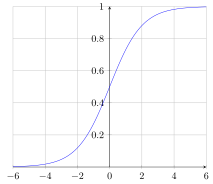

In [5]:
%%tikz -t=pgfplots
\pgfmathdeclarefunction{gauss}{3}{%
  \pgfmathparse{1/(#3*sqrt(2*pi))*exp(-((#1-#2)^2)/(2*#3^2))}%
}

    \begin{tikzpicture}
    \begin{axis}%
    [
        grid=major,     
        xmin=-6,
        xmax=6,
        axis x line=bottom,
        %yticklabel pos=right,
        %ytick={0,.5,1},
        ymin=0,
        ymax=1,
        axis y line=middle,
    ]
        \addplot%
        [
            blue,
            mark=none,
            samples=100,
            domain=-6:6,
        ]
        (x,{1/(1+exp(-x))});
    \end{axis}
    \end{tikzpicture}

We can interpret this curve as telling us "the probability that the data point is in category 1 is $p(x)$, and the probability that the data point is in category 2 is $1 - p(x)$." Therefore, probabilities sum to 1, because there is a 100% chance of the data point belonging to _some_ category.

If we have _more_ than two categories we must use _multinomial logistic regression._ (Organ music plays) Here we have multiple S-shaped curves, and the probabilities across all curves must sum to one. For a given category $i$ this can be expressed as:

$$p_i(X) = \frac{e^{\beta_i \cdot X}}{1 + \sum_{u=1}^{n} e^{\beta_u \cdot x}}$$

Now let's apply this theory to the _Iris dataset._ This is a classification dataset containing three kinds of irisis (Setosa, Versicolour, and Virginica). For each flower, we've recorded the sepal length and width, and the petal length and width, giving us four numeric features in centimeters and 150 example flowers.

In [6]:
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)
print(X[:5,:])
print(y)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [7]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=0,max_iter=1000).fit(X,y)
print("Predicted labels for first two flowers:")
print(clf.predict(X[:2, :]))
print("Probabilities for each class for first two flowers:")
print(clf.predict_proba(X[:2, :]))
print("Accuracy across all flowers:")
print(clf.score(X, y))

Predicted labels for first two flowers:
[0 0]
Probabilities for each class for first two flowers:
[[9.81567923e-01 1.84320627e-02 1.44928093e-08]
 [9.71336447e-01 2.86635225e-02 3.01765481e-08]]
Accuracy across all flowers:
0.9733333333333334


____
### What is a 'Good' model?

A perfect classification model labels every data point correctly. But what if our model is only pretty good? How do we describe how good it is? We have a great many metrics to choose from. Common choices include:

* Accuracy: $\frac{correct\ classifications}{total\ classifications} = \frac{TP + TN}{TP + TN + FP + FN}$

* Recall: $\frac{correct\ positives}{all\ positives} = \frac{TP}{TP + FN}$, "how many of the positives did we find?"

* False Positive Rate (FPR): $\frac{incorrect\ negatives}{all\ actual\ negatives} = \frac{FP}{FP + TN}$

* Precision: $\frac{correct\ positives}{everything\ marked\ as\ positive} = \frac{TP}{TP + FP}$, "when we marked something as positive, how often were we right?"

* F1 score (balanced F-score): $\frac{2 * TP}{2 * TP + FP + FN}$, harmonic mean of precision and recall

* Matthews correlation coefficient (MCC): $\frac{TP * TN - FP * FN}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}$

Why so many? Because a 'good' model is context-dependent. In a medical test, maybe we care about identifying sick people for treatment, and accidentally treating a few healthy people is preferable to missing a few sick people. For your spam filter, maybe you'll be a little annoyed if an occasional spam email filters through, but you'll be _very_ annoyed if an important email goes into your spam filter unnoticed.

In addition to the subjective importance of false positives and false negatives, some of the scores above suffer under **class imbalance**. In the iris dataset we have three classes of irisis, and they are equally represented (50 each). But what if 80% of the flowers were Iris Virginica? You'll now get very skewed values, where a high accuracy score may not mean much - if you always guess Iris Virginica you'll get 80% accuracy! With imbalanced datasets we typically prefer the F1 score or MCC, which are more robust but less intuitive.

----

### Decision Trees

Linear and logistic regression are both line-fitting algorithms. We will now introduce a different family of machine-learning approaches: _decision trees._ This is set of algorithms that sub-divides your dataset into small regions, ultimately producing a flowchart to yield predictions. Decision trees are referred to as _classification trees_ when used for classification, and _regression trees_ when used for regression, but the techniques are almost identical.

Let's begin with a dataset of blue squares and orange circles (our categorical labels), each of which have an X and Y value.

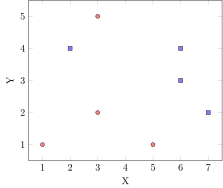

In [8]:
%%tikz -t=pgfplots -l=backgrounds

\pgfplotsset{compat=1.11}
\begin{tikzpicture}
\begin{axis}[%
xmin=0.5,xmax=7.5,
ymin=0.5,ymax=5.5,
xlabel=X,ylabel=Y,
scatter/classes={%
    a={draw=black,fill=red!50},
    b={mark=square*,draw=black,fill=blue!50}}]
\addplot[scatter,only marks,%
    scatter src=explicit symbolic]%
table[meta=label] {
x y label
2 4 b
3 5 a
3 2 a
1 1 a
5 1 a
6 3 b
6 4 b
7 2 b
    };
\end{axis}
\end{tikzpicture}

We now try to place a vertical line that best separates the squares and circles, and a horizontal line that best separates the classes. We'll keep whichever line works best.

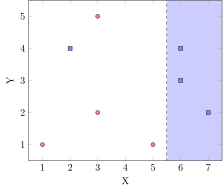

In [9]:
%%tikz -t=pgfplots -l=backgrounds

\pgfplotsset{compat=1.11}
\begin{tikzpicture}
\begin{axis}[%
xmin=0.5,xmax=7.5,
ymin=0.5,ymax=5.5,
xlabel=X,ylabel=Y,
scatter/classes={%
    a={draw=black,fill=red!50},
    b={mark=square*,draw=black,fill=blue!50}}]
\begin{scope}[on background layer]
    \draw[draw=none,fill=blue!20] (5.5,0.5) rectangle (7.5,5.5);
\end{scope}
\addplot[mark=none, black, dashed] coordinates {(5.5,-1) (5.5,6.25)};
\addplot[scatter,only marks,%
    scatter src=explicit symbolic]%
table[meta=label] {
x y label
2 4 b
3 5 a
3 2 a
1 1 a
5 1 a
6 3 b
6 4 b
7 2 b
    };
\end{axis}
\end{tikzpicture}

The right partition contains only blue squares, so we're done processing it. The left partition can be further sub-divided, so we repeat the process recursively. First we add another vertical line:

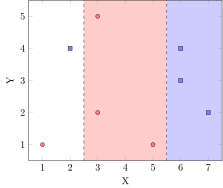

In [10]:
%%tikz -t=pgfplots -l=backgrounds

\pgfplotsset{compat=1.11}
\begin{tikzpicture}
\begin{axis}[%
xmin=0.5,xmax=7.5,
ymin=0.5,ymax=5.5,
xlabel=X,ylabel=Y,
scatter/classes={%
    a={draw=black,fill=red!50},
    b={mark=square*,draw=black,fill=blue!50}}]
\begin{scope}[on background layer]
    \draw[draw=none,fill=blue!20] (5.5,0.5) rectangle (7.5,5.5);
    \draw[draw=none,fill=red!20] (2.5,0.5) rectangle (5.5,5.5);
\end{scope}
\addplot[mark=none, black, dashed] coordinates {(5.5,-1) (5.5,6.25)};
\addplot[mark=none, black, dashed] coordinates {(2.5,-1) (2.5,6.25)};
\addplot[scatter,only marks,%
    scatter src=explicit symbolic]%
table[meta=label] {
x y label
2 4 b
3 5 a
3 2 a
1 1 a
5 1 a
6 3 b
6 4 b
7 2 b
    };
\end{axis}
\end{tikzpicture}

Then we add a horizontal line:

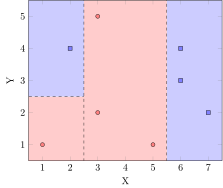

In [11]:
%%tikz -t=pgfplots -l=backgrounds

\pgfplotsset{compat=1.11}
\begin{tikzpicture}
\begin{axis}[%
xmin=0.5,xmax=7.5,
ymin=0.5,ymax=5.5,
xlabel=X,ylabel=Y,
scatter/classes={%
    a={draw=black,fill=red!50},
    b={mark=square*,draw=black,fill=blue!50}}]
\begin{scope}[on background layer]
    \draw[draw=none,fill=blue!20] (5.5,0.49) rectangle (7.5,5.5);
    \draw[draw=none,fill=red!20] (2.5,0.49) rectangle (5.5,5.5);
    \draw[draw=none,fill=red!20] (0.49,0.49) rectangle (2.5,2.5);
    \draw[draw=none,fill=blue!20] (0.49,2.5) rectangle (2.5,5.5);
\end{scope}
\addplot[mark=none, black, dashed] coordinates {(5.5,-1) (5.5,6.25)};
\addplot[mark=none, black, dashed] coordinates {(2.5,-1) (2.5,6.25)};
\addplot[mark=none, black, dashed] coordinates {(-1,2.5) (2.5,2.5)};
\addplot[scatter,only marks,%
    scatter src=explicit symbolic]%
table[meta=label] {
x y label
2 4 b
3 5 a
3 2 a
1 1 a
5 1 a
6 3 b
6 4 b
7 2 b
    };
\end{axis}
\end{tikzpicture}

We can define several stopping conditions for building our tree. Maybe we stop once a partition has below three data points in it. Maybe we stop at a maximum depth of four. Maybe we stop once most or all of the points in a partition have the same label.

Here's the above in our new favorite package `sklearn`:

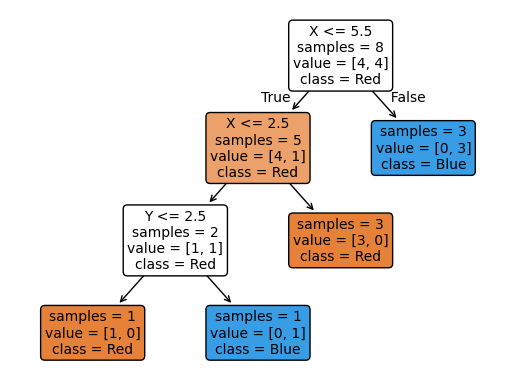

In [92]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
X = [
    [2, 4],
    [3, 5],
    [3, 2],
    [1, 1],
    [5, 1],
    [6, 3],
    [6, 4],
    [7, 2]
    ]
y = [1, 0, 0, 0, 0, 1, 1, 1]

clf = DecisionTreeClassifier()
clf = clf.fit(X, y)
plot_tree(clf, feature_names=["X", "Y"], class_names=["Red", "Blue"], filled=True, rounded=True, impurity=False, fontsize=10)
plt.show()

This is magnificent! If neural networks are a black box where it's difficult to understand how the model comes to a conclusion, decision trees are the inverse, where it is transparently clear how decisions are made. My mantra: _if your machine learning task is simple enough to solve with a flowchart then you should always solve it with a flowchart._

#### Regression Trees

When applying decision trees to regression problems instead of classification problems, the algorithm is almost identical. As with classification trees, regression trees divide data points into partitions that maximize variance between the partitions, and minimize variance within the partitions. However, the regression tree predicts values using the _mean_ of the points within a partition, while a classification tree uses the _mode._ We also measure performance differently for regression and classification trees - metrics like "mean squared error" are undefined for categorical data.

### Your turn!

Apply Decision Trees to either the curve-fitting problem, or the Iris classification problem. Both if you have time! How can you plot or print the performance of your trees? How did you have to constrain your trees to prevent overfitting? _Did_ you prevent overfitting?

In [46]:
# For the curve-fitting problem
from sklearn.tree import DecisionTreeRegressor

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 30

X = np.sort(np.random.rand(n_samples))
X_rotated = X.reshape(-1, 1) # Make this an Nx1 array instead of 1xN
y = true_fun(X) + np.random.randn(n_samples) * 0.1 # True function with a little noise

# Here's a regression tree, with five parameters you may want to fiddle with
reg = DecisionTreeRegressor(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_leaf_nodes=None,
    min_impurity_decrease=0
).fit(X_rotated, y)

# Your code here...

In [32]:
# For the Iris classification problem
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)

# Here's a classification tree, with five parameters you may want to fiddle with
clf = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_leaf_nodes=None,
    min_impurity_decrease=0
).fit(X, y)

# Your code here...

#### Reference solution, do not look below

<Figure size 640x480 with 0 Axes>

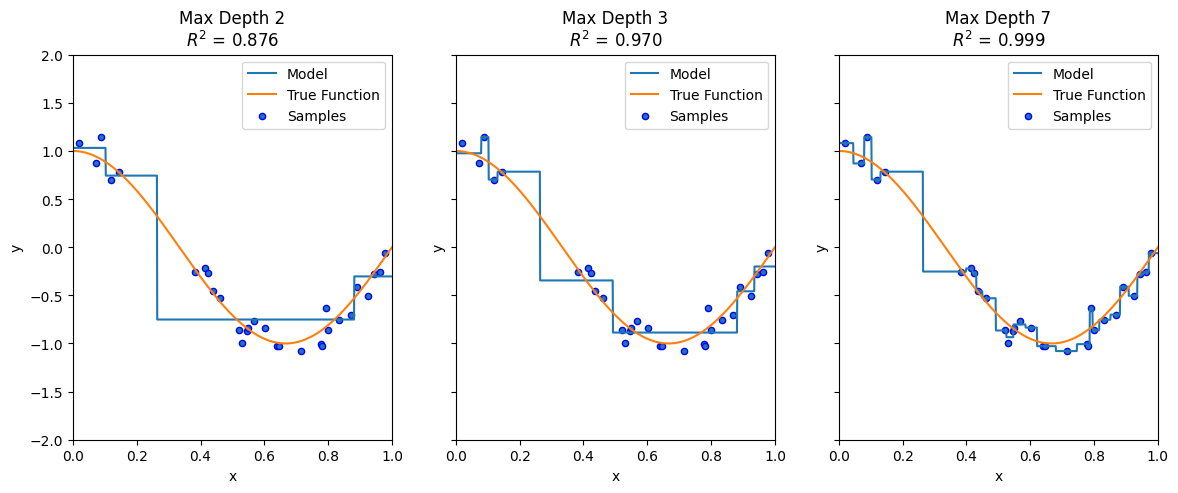

In [45]:
# For the curve-fitting problem
from sklearn.tree import DecisionTreeRegressor

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 30

X = np.sort(np.random.rand(n_samples))
X_rotated = X.reshape(-1, 1) # Make this an Nx1 array instead of 1xN
y = true_fun(X) + np.random.randn(n_samples) * 0.1 # True function with a little noise

X_test = np.linspace(0, 1, 1000)
X_test_rotated = X_test.reshape(-1,1)

plt.clf()
fig, axs = plt.subplots(1, 3, figsize=(14,5), sharex=True, sharey=True)
for i,max_depth in enumerate([2, 3, 7]):
    reg = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=2,
        min_samples_leaf=1,
        max_leaf_nodes=None
    ).fit(X_rotated, y)

    score = reg.score(X_rotated, y)
    y_pred = reg.predict(X_test_rotated)

    ax = axs[i]
    ax.plot(X_test, reg.predict(X_test_rotated), label="Model")
    ax.plot(X_test, true_fun(X_test), label="True Function")
    ax.scatter(X, y, edgecolor="b", s=20, label="Samples")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.xlim((0,1))
    plt.ylim((-2,2))
    ax.legend(loc="best")
    ax.set_title("Max Depth %d\n$R^2$ = %.3f" % (max_depth,score))
    
#plt.suptitle("Decision Tree Regression")
plt.show()

Max-depth 2 has a score of 0.960
Max-depth 3 has a score of 0.973
Max-depth 5 has a score of 0.993


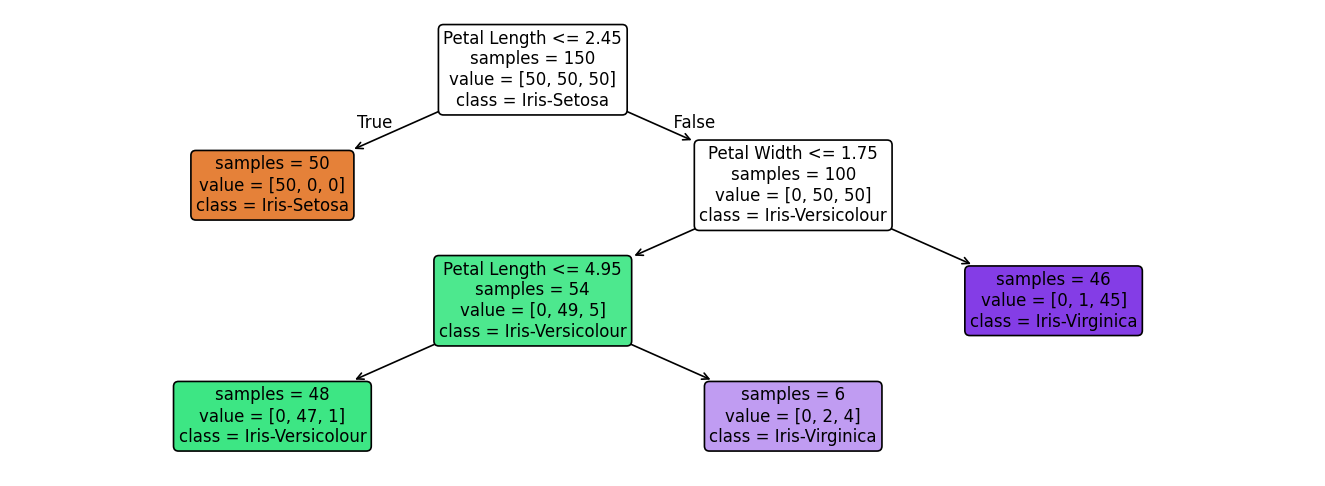

In [30]:
# For the Iris classification problem
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)

trees = []

for max_depth in [2, 3, 5]:
    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=2,
        min_samples_leaf=1,
        min_impurity_decrease=0.005,
        max_leaf_nodes=None
    ).fit(X, y)
    score = clf.score(X, y)
    print("Max-depth %d has a score of %.3f" % (max_depth,score))
    trees.append(clf)

feature_names = ["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"]
class_names = ["Iris-Setosa", "Iris-Versicolour", "Iris-Virginica"]
plt.figure(figsize=(14, 5), dpi=120)
plot_tree(trees[1], feature_names=feature_names, class_names=class_names, filled=True, rounded=True, impurity=False, fontsize=10)
plt.show()

### Limitation of Trees

Trees are brave and true and morally correct, but they do have a number of downsides:

* They are prone to overfitting, and must be carefully constrained

* They are bad at extrapolation: linear regression can predict a y-value based on a trajectory from a known data point, while decision trees can only bin y-values to the closest data point

* They can produce poor trees for heavily biased datasets

### Random Forests

What do we do when trees overfit? **Add more trees!!**

Decision trees are prone to overfitting. One solution to this problem is to create multiple decision trees, each trained on a subset of the available features. Each tree may overfit to the training data, but they'll overfit in _different ways._ We can average the predictions from each tree and get a superior aggregate result. We call this collection of random-feature trees a _Random Forest._ In general, models that average the results of other models are called _ensemble models._

Random forests perform much better than trees, and are often included as a baseline when measuring the performance of more advanced models. Trees and forests also have one last advantage: they can easily report how useful each feature was in prediction. Observe!

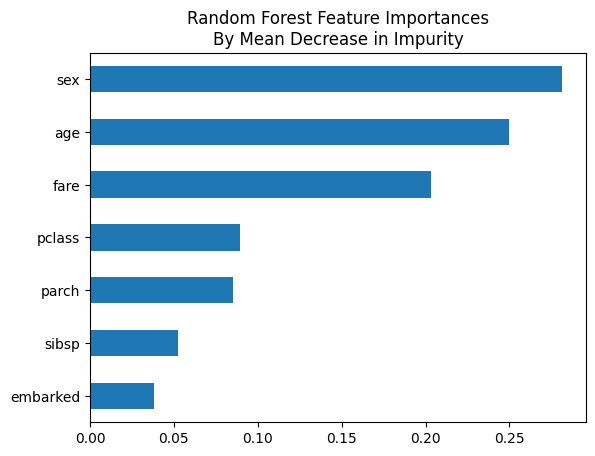

In [93]:
# Adapted from https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html

from sklearn.datasets import fetch_openml
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

X, y = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True)

categorical_columns = ["pclass", "sex", "embarked"]
numerical_columns = ["age", "sibsp", "parch", "fare"]
# Reorder columns and drop irrelevant data
X = X[categorical_columns + numerical_columns]

categorical_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1)
numerical_pipe = SimpleImputer(strategy="mean")
preprocessing = ColumnTransformer(
    [
        ("cat", categorical_encoder, categorical_columns),
        ("num", numerical_pipe, numerical_columns),
    ],
    verbose_feature_names_out=False,
)

X = preprocessing.fit_transform(X)

rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X, y)

feature_names = categorical_columns + numerical_columns
mdi_importances = pd.Series(rf[-1].feature_importances_, index=feature_names).sort_values(ascending=True)
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances\nBy Mean Decrease in Impurity")
plt.show()

------

### Test / Train Splits

So far we have trained our models on all of our example data points, and then measured the model's performance by how well it predicts those same data points. This is a recipe for disastrous overfitting. The model can easily memorize all inputs and achieve perfect accuracy that's useless in the real world!

Instead, we typically want to train on some data points, and test performance on a second set of points. How many? It's a tradeoff: more training data will improve our model, but we want to withold enough data for testing to be confident about our model performance.

One unprincipled and clumsy rule of thumb is the 80-20 split: use 80% of our data for training, 20% for testing. Let's give it a shot! Starting with the line-fitting problem once again:

Linear regression R^2 train: 0.931
Linear regression R^2 test: 0.872
Regression Tree R^2 train: 0.999
Regression Tree R^2 test: 0.979


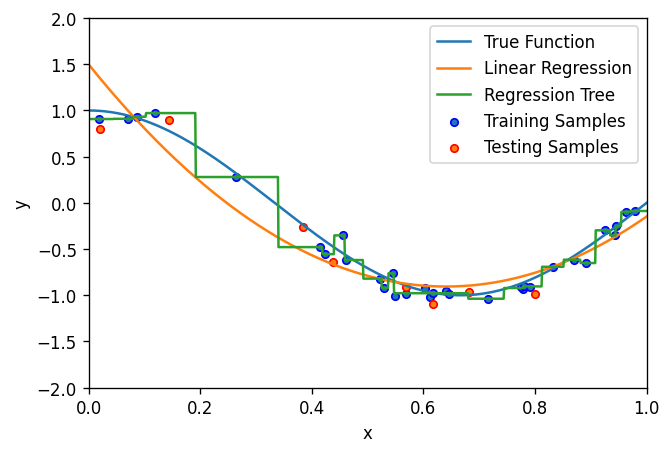

In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 40
linear_regression_polynomial = 2
tree_depth = 7

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1 # True function with a little noise
X_rotated = X.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X_rotated, y, train_size=0.8)

train_expanded_features = PolynomialFeatures(linear_regression_polynomial).fit_transform(X_train)
test_expanded_features = PolynomialFeatures(linear_regression_polynomial).fit_transform(X_test)

lreg = LinearRegression().fit(train_expanded_features, y_train)
treg = DecisionTreeRegressor(max_depth=tree_depth).fit(X_train, y_train)

print("Linear regression R^2 train: %.3f" % lreg.score(train_expanded_features, y_train))
print("Linear regression R^2 test: %.3f" % lreg.score(test_expanded_features, y_test))
print("Regression Tree R^2 train: %.3f" % treg.score(X_train, y_train))
print("Regression Tree R^2 test: %.3f" % treg.score(X_test, y_test))

X_plot = np.linspace(0, 1, 1000)
X_plot_rotated = X_plot.reshape(-1,1)
X_plot_expanded = PolynomialFeatures(linear_regression_polynomial).fit_transform(X_plot_rotated)

plt.figure(figsize=(6,4), dpi=120)
plt.plot(X_plot, true_fun(X_plot), label="True Function")
plt.plot(X_plot, lreg.predict(X_plot_expanded), label="Linear Regression")
plt.plot(X_plot, treg.predict(X_plot_rotated), label="Regression Tree")
plt.scatter(X_train.reshape(-1, 1), y_train, edgecolor="b", s=20, label="Training Samples")
plt.scatter(X_test.reshape(-1, 1), y_test, edgecolor="r", s=20, label="Testing Samples")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim((0,1))
plt.ylim((-2,2))
plt.legend(loc="best")
plt.show()

This is a good start: already we can see how linear regression did _okay_ at capturing the training data, but didn't match the original pattern well enough to do so well on our hold-out testing data. Meanwhile, the regression tree overfit to the training data by a great deal and performs a little worse on the test data.

However, the 80-20 rule can easily get us in trouble. The big concern is _class imbalance._ For a regression task: what if most of the training data is in the lower-right portion of the plot, and most of the test data is in the upper left? For a classification task: what if the training data consists mostly of Iris-Setosa and Iris-Versicolour, but the test data consists mostly of Iris-Virginica? This can be especially challenging if one class is rare to begin with, and absent or nearly absent in the training data.

There are a variety of solutions to this problem. Here are two:

1. Perform a _stratified_ split. Still an 80-20 (or any other sized) shuffle, but we now maintain approximately the same ratio of classes in train and test data.

2. Perform _cross validation._ Here we perform an 80-20 split many times, and report average model performance. This can be especially useful in regression tasks where there aren't clear categorical classes, but we want to be sure the model didn't receive an "easy" or "hard" training set.

### The Model Complexity Tradeoff

Generally, simple models are less flexible and require that you specify more of the solution upfront. For example, linear regression fit a polynomial, but only when we specified the degree of the polynomial as a hyperparameter. However, simple models are fast to train, require comparatively little data, and are easier to explain. This makes them preferable for causal inference, when we are trying to understand a relationship and what causes a pattern to emerge.

More sophisticated models are more flexible, and can discover patterns with less of the structure pre-defined. However, these models require much more training data, are slow to train, and are much more difficult to explain. They can often get higher performance in classification and regression tasks, but are less useful for causal inference. These are more common in industry applications where making the tool work better is prioritized over answering scientific question.

A very hand-wavey scale of model complexity might be:

Decision Trees / Linear Regression -> LASSO / Ridge Regression / Support Vector Machines / Forests -> Neural Networks / Larger Ensembles / Boosted Ensembles -> Deep and Convolution Neural Networks -> High parameter models like LLMs

### Assorted ML Topics

1. Feature preparation: normalization (MinMaxScaling), discretizing (binning, ordinalization, one-hot encoding), polynomialization

2. Missing data: Dropping rows versus imputation, different imputation strategies

3. De-correlation through dimensionality reduction (PCA, LDA, t-SNE, UMAP)




__________
## Next time...
Spring break! And then... Network Dynamics and Reconstruction!

_______

## References and further resources:

1. Class Webpages
    - Github: https://github.com/network-science-data-and-models/cnet5052_sp26
    - Syllabus and course details: https://brennanklein.com/cnet5052-spring26
2. Statistical Learning, especially their textbook for Python: https://www.statlearning.com/